In [11]:
import pandas as pd
import numpy as np

# Chargement
df = pd.read_excel("Base_ER_FR.xlsx")

# Aperçu
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ID           100000 non-null  str    
 1   AGE_CLI      99524 non-null   float64
 2   B_MAT        98620 non-null   float64
 3   B_RESMAT     98620 non-null   float64
 4   CLASSACT     100000 non-null  int64  
 5   CSP          97522 non-null   float64
 6   DARRET       100000 non-null  int64  
 7   E_EAD        98620 non-null   float64
 8   E_OFF        98620 non-null   float64
 9   E_ONB        98620 non-null   float64
 10  MREVAU       99954 non-null   float64
 11  MREVNU       99954 non-null   float64
 12  MREVTOT      99954 non-null   float64
 13  MTECH        100000 non-null  float64
 14  NBIMP        100000 non-null  int64  
 15  NB_ECH       100000 non-null  int64  
 16  produit      100000 non-null  str    
 17  RA           100000 non-null  float64
 18  Tx           95114 non-null   float6

suppréssion des colonnes inutiles 

In [12]:
cols_to_drop = [
    "Unnamed: 19",
    "MREVAU",
    "MREVNU"
]

df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)


conversion de la date d'arreté

In [13]:
# DARRET au format YYYYMM → datetime
df["DARRET"] = pd.to_datetime(
    df["DARRET"].astype(str) + "01",
    format="%Y%m%d",
    errors="coerce"
)

df["DARRET"].isna().mean()


np.float64(0.0)

Encours/ EAD 

In [ ]:
# Vérification de redondance
df[["E_EAD", "E_ONB"]].describe()

,E_EAD,E_ONB
count,98620.000000,98620.000000
mean,998.009810,998.009810
std,5744.202071,5744.202071
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.190000,0.190000
max,267563.810000,267563.810000


In [ ]:
#ATTENTION : 

# Si quasi identiques :
df["EAD"] = df["E_EAD"]

df.drop(columns=["E_EAD", "E_ONB"], inplace=True, errors="ignore")


Nettoyage économique de base

In [16]:
# EAD strictement positif
df = df[df["EAD"] >= 0]

# RA cohérent
df["RA"] = df["RA"].fillna(0)
df = df[df["RA"] <= df["EAD"]]


Typage des variables catégorielles

In [17]:
cat_cols = ["CLASSACT", "CSP", "produit"]

for c in cat_cols:
    df[c] = df[c].astype("category")


Valeurs manquantes ne pas drop

In [18]:
missing = df.isna().mean().sort_values(ascending=False)
missing


Tx          0.030903
CSP         0.007227
AGE_CLI     0.004984
MREVTOT     0.000623
ID          0.000000
B_MAT       0.000000
DARRET      0.000000
E_EAD       0.000000
B_RESMAT    0.000000
CLASSACT    0.000000
E_ONB       0.000000
E_OFF       0.000000
NBIMP       0.000000
MTECH       0.000000
NB_ECH      0.000000
produit     0.000000
RA          0.000000
EAD         0.000000
dtype: float64

Imputation du taux tx

In [19]:
# Imputation par médiane du produit
df["Tx"] = df.groupby("produit")["Tx"].transform(
    lambda x: x.fillna(x.median())
)

# Si jamais un produit a tout NA (rare)
df["Tx"] = df["Tx"].fillna(df["Tx"].median())


Imputation CSP

In [20]:
df["CSP"] = df["CSP"].cat.add_categories("Inconnu")
df["CSP"] = df["CSP"].fillna("Inconnu")


Imputation AGE_CLI et revenu

In [21]:
df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())
df["MREVTOT"] = df["MREVTOT"].fillna(df["MREVTOT"].median())


Vérification 

In [22]:
df.isna().mean().sort_values(ascending=False)


ID          0.0
AGE_CLI     0.0
B_MAT       0.0
B_RESMAT    0.0
CLASSACT    0.0
CSP         0.0
DARRET      0.0
E_EAD       0.0
E_OFF       0.0
E_ONB       0.0
MREVTOT     0.0
MTECH       0.0
NBIMP       0.0
NB_ECH      0.0
produit     0.0
RA          0.0
Tx          0.0
EAD         0.0
dtype: float64

### variables ifrs9

Age du pret : B_MAT : maturité initiale (en mois)

B_RESMAT : maturité restante (en mois)

AGE_PRET=B_MAT−B_RESMAT

In [23]:
# Âge du prêt en mois
df["AGE_PRET"] = df["B_MAT"] - df["B_RESMAT"]

# Contrôles
df["AGE_PRET"].describe()


count    8025.000000
mean       29.719252
std        32.000410
min       -81.000000
25%        10.000000
50%        21.000000
75%        40.000000
max       299.000000
Name: AGE_PRET, dtype: float64

In [24]:
# Âge négatif ou incohérent = erreur
df = df[df["AGE_PRET"] >= 0]
df = df[df["AGE_PRET"] <= df["B_MAT"]]


Horizon résiduel : pour projeter EAD et contruire ER par age

In [25]:
df["HORIZON_RES"] = df["B_RESMAT"].astype(int)


Cash flow de capital observé au mois de l’arrêté

In [26]:
df["CF_CAP_OBS"] = df["RA"].fillna(0)


Remboursement anticipé observé

In [27]:
df["ER_obs"] = df["RA"] / df["EAD"]

# Nettoyage
df["ER_obs"] = df["ER_obs"].clip(lower=0, upper=1)


In [28]:
df["ER_obs"].describe()
df["ER_obs"].quantile([0.9, 0.95, 0.99])


0.90    0.737261
0.95    0.877241
0.99    0.986334
Name: ER_obs, dtype: float64

# Analyse de la distribution des remboursements anticipés observés (ER_obs)

## 1. Résultats empiriques

Les quantiles empiriques de la variable de remboursement anticipé observé `ER_obs` sont les suivants :

- Quantile 90 % : 0.737  
- Quantile 95 % : 0.877  
- Quantile 99 % : 0.986  

Ces valeurs indiquent que, lorsque des remboursements anticipés ont lieu, ils représentent fréquemment une part très importante de l’exposition initiale.

---

## 2. Interprétation économique

Ces quantiles élevés ne constituent pas une anomalie des données. Ils traduisent un comportement standard sur les portefeuilles de crédits amortissables, en particulier en crédit à la consommation.

Lorsqu’un remboursement anticipé intervient, il correspond le plus souvent à :
- une clôture anticipée du contrat,
- un rachat de crédit,
- un remboursement quasi total de l’encours restant.

Il est donc économiquement cohérent d’observer des valeurs de `ER_obs` proches de 1 dans la queue de distribution.

---

## 3. Structure distributionnelle de ER_obs

La distribution de `ER_obs` présente deux caractéristiques majeures :

- une **masse importante à zéro**, correspondant aux contrats sans remboursement anticipé ;
- une **queue droite lourde**, correspondant aux contrats remboursés partiellement ou totalement par anticipation.

Cette structure est fortement asymétrique et s’écarte nettement d’une distribution gaussienne.

---

## 4. Implications pour la modélisation

### 4.1 Approches à éviter

Compte tenu des propriétés empiriques observées, les approches suivantes sont inadaptées :

- régression linéaire directe sur `ER_obs` ;
- hypothèse de normalité de la variable cible ;
- modélisation ignorant la masse à zéro.

Ces choix conduiraient à des estimations instables et difficilement interprétables économiquement.

---

### 4.2 Approches adaptées

#### Approche 1 – Modélisation en deux étapes (recommandée)

La modélisation peut être décomposée en deux composantes :

1. la probabilité qu’un remboursement anticipé ait lieu :
   
   $$
   \mathbb{P}(RA > 0)
   $$

2. l’intensité du remboursement anticipé conditionnellement à son occurrence :
   
   $$
   ER^{obs} \mid RA > 0
   $$

Cette approche permet de distinguer la décision de rembourser par anticipation du montant effectivement remboursé.

---

#### Approche 2 – Capping pour les analyses exploratoires

Pour certaines analyses descriptives ou modèles de référence, il est possible de plafonner les valeurs extrêmes afin d’améliorer la stabilité des résultats.

Exemple :

```python
df["ER_obs_cap"] = df["ER_obs"].clip(upper=0.95)


Indicateur de remboursement anticipé

In [29]:
df["FLAG_ER"] = (df["RA"] > 0).astype(int)

df["FLAG_ER"].mean()


np.float64(0.8411543287327478)

EAD IFRS 9 cohérente (post-ER)

In [30]:
df["EAD_POST"] = df["EAD"] - df["RA"]
df["EAD_POST"] = df["EAD_POST"].clip(lower=0)


## Analyse exploratoire 

ER moyen par âge du prêt

In [40]:
# ER moyen par âge du prêt
er_by_age = (
    df.groupby("AGE_PRET")["ER_obs"]
    .mean()
    .reset_index()
)

er_by_age.head()


,AGE_PRET,ER_obs
0,0.0,0.343086
1,1.0,0.417501
2,2.0,0.331582
3,3.0,0.247252
4,4.0,0.282648


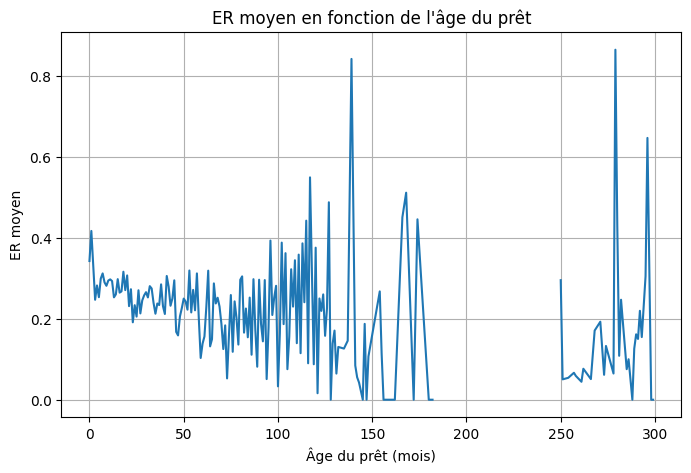

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(er_by_age["AGE_PRET"], er_by_age["ER_obs"])
plt.xlabel("Âge du prêt (mois)")
plt.ylabel("ER moyen")
plt.title("ER moyen en fonction de l'âge du prêt")
plt.grid(True)
plt.show()


#### Résultat observé

La figure ci-dessus représente l’évolution du remboursement anticipé moyen (`ER_obs`) en fonction de l’âge du prêt (en mois).

Interprétation

Pour les âges faibles à intermédiaires (environ de 0 à 120 mois), l’ER moyen est relativement stable, autour de 20–30 %, avec des fluctuations modérées. Cette stabilité suggère que, lorsque des remboursements anticipés ont lieu en début ou milieu de vie du prêt, ils sont généralement partiels.

À partir d’âges plus élevés (au-delà de 120–150 mois), la courbe devient fortement instable, avec des pics très élevés pouvant atteindre 80–90 %, ainsi que des valeurs proches de zéro. Cette instabilité ne traduit pas un changement structurel du comportement, mais résulte principalement d’un faible nombre d’observations à ces âges avancés.

Sur le plan économique, ces valeurs élevées correspondent à des remboursements anticipés de fin de vie du contrat, souvent assimilables à des clôtures anticipées, impliquant un remboursement quasi total de l’exposition restante.

 Implication méthodologique

Ces résultats confirment l’existence d’une dépendance marquée entre l’intensité du remboursement anticipé et l’âge du prêt, tout en soulignant la nécessité d’agréger les âges élevés ou de borner l’horizon de modélisation afin de limiter le bruit statistique.



## Taux de remboursement anticipé (FLAG_ER) par âge du prêt

In [35]:
flag_by_age = (
    df.groupby("AGE_PRET")["FLAG_ER"]
    .mean()
    .reset_index()
)

flag_by_age.head()


,AGE_PRET,FLAG_ER
0,0.0,0.916667
1,1.0,0.845238
2,2.0,0.842697
3,3.0,0.835052
4,4.0,0.887755


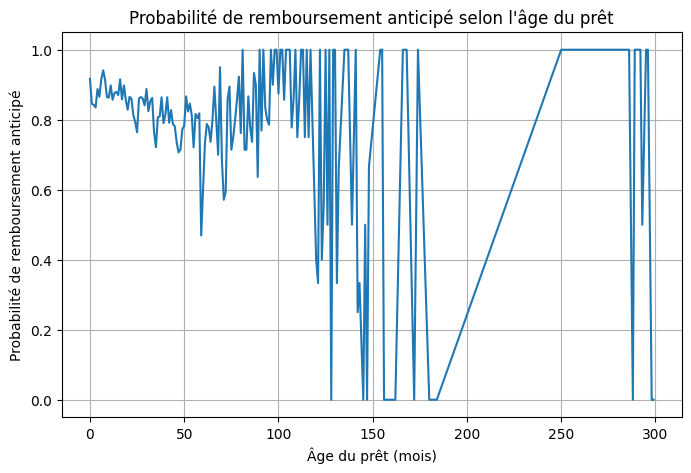

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(flag_by_age["AGE_PRET"], flag_by_age["FLAG_ER"])
plt.xlabel("Âge du prêt (mois)")
plt.ylabel("Probabilité de remboursement anticipé")
plt.title("Probabilité de remboursement anticipé selon l'âge du prêt")
plt.grid(True)
plt.show()



Résultat observé

La figure ci-dessus présente la probabilité empirique de remboursement anticipé (`FLAG_ER`) en fonction de l’âge du prêt.

Interprétation

Pour les âges faibles à intermédiaires, la probabilité de remboursement anticipé apparaît élevée, généralement comprise entre 80 % et 90 %. Cette valeur élevée doit être interprétée avec prudence, car l’analyse est menée par âge exact, ce qui peut conduire à des proportions instables lorsque le nombre d’observations est limité.

Aux âges plus élevés, la courbe devient extrêmement erratique, alternant brutalement entre des probabilités nulles et unitaires. Ce comportement est caractéristique de classes d’âge peu peuplées, pour lesquelles quelques observations suffisent à faire varier fortement la moyenne.

Implication méthodologique

Ces résultats suggèrent que le remboursement anticipé n’est pas un événement rare dans le portefeuille étudié, mais qu’il présente une forte hétérogénéité temporelle. Ils plaident en faveur d’une modélisation reposant sur des classes d’âge agrégées et d’une distinction explicite entre l’occurrence du remboursement anticipé et son intensité.


### ER par produit

In [37]:
er_by_product = (
    df.groupby("produit")
    .agg(
        taux_ER=("FLAG_ER", "mean"),
        ER_moyen=("ER_obs", "mean"),
        n_obs=("ER_obs", "size")
    )
    .sort_values("taux_ER", ascending=False)
)

er_by_product


,taux_ER,ER_moyen,n_obs
produit,,,
AMO,0.84292,0.260405,7945
AR,0.28000,0.061900,25



Le produit **AMO** constitue l’essentiel du portefeuille et présente un taux élevé de remboursements anticipés, avec une intensité moyenne modérée. Ce comportement est cohérent avec des remboursements anticipés fréquents mais souvent partiels.

À l’inverse, le produit **AR** est très faiblement représenté dans l’échantillon. Les résultats associés à ce produit sont statistiquement peu fiables et ne permettent pas de tirer de conclusions robustes.

Implication méthodologique

Compte tenu du faible volume associé au produit AR, celui-ci devra être exclu de la phase de modélisation ou regroupé avec d’autres produits, afin de garantir la robustesse statistique des estimations.


### ER par classes de taux (Tx)

On discrétise le taux en classes (quartiles).

In [38]:
df["Tx_bin"] = pd.qcut(df["Tx"], q=4, duplicates="drop")

er_by_tx = (
    df.groupby("Tx_bin")
    .agg(
        taux_ER=("FLAG_ER", "mean"),
        ER_moyen=("ER_obs", "mean"),
        n_obs=("ER_obs", "size")
    )
)

er_by_tx


,taux_ER,ER_moyen,n_obs
Tx_bin,,,
"(-1.501, 2.094]",0.813942,0.295410,1994
"(2.094, 2.181]",0.834502,0.270175,2139
"(2.181, 2.256]",0.852225,0.244441,1888
"(2.256, 2.786]",0.865572,0.228705,1949


Les classes de taux montrent une augmentation progressive du taux de remboursement anticipé lorsque le taux contractuel augmente, tandis que l’intensité moyenne du remboursement anticipé diminue légèrement.

Interprétation économique

Deux effets distincts apparaissent :

- **Effet d’incitation** : des taux contractuels plus élevés augmentent l’intérêt économique du remboursement anticipé, ce qui se traduit par une probabilité plus élevée de remboursement.
- **Effet de structure** : bien que plus fréquents, les remboursements anticipés associés aux taux élevés sont en moyenne moins intenses, suggérant des remboursements partiels plutôt que des clôtures complètes.

Implication méthodologique

Le taux contractuel apparaît comme une variable explicative clé du remboursement anticipé, avec un effet potentiellement non linéaire, justifiant son intégration explicite dans les modèles ultérieurs.


### ER par maturité restante (B_RESMAT)

On regroupe la maturité restante en classes.

In [39]:
df["B_RESMAT_bin"] = pd.cut(df["B_RESMAT"], bins=10)

er_by_resmat = (
    df.groupby("B_RESMAT_bin")
    .agg(
        taux_ER=("FLAG_ER", "mean"),
        ER_moyen=("ER_obs", "mean"),
        n_obs=("ER_obs", "size")
    )
)

er_by_resmat


,taux_ER,ER_moyen,n_obs
B_RESMAT_bin,,,
"(-0.276, 27.6]",0.773254,0.312755,2677
"(27.6, 55.2]",0.879379,0.231341,2512
"(55.2, 82.8]",0.871192,0.226914,1149
"(82.8, 110.4]",0.857633,0.202845,583
"(110.4, 138.0]",0.871087,0.261765,543
"(138.0, 165.6]",0.897541,0.269772,244
"(165.6, 193.2]",0.898785,0.277115,247
"(193.2, 220.8]",0.600000,0.158878,10
"(220.8, 248.4]",1.000000,0.157061,2


Les résultats montrent des comportements différenciés selon la maturité restante du prêt :

- pour les maturités faibles, les remboursements anticipés sont moins fréquents mais plus intenses ;
- pour les maturités intermédiaires, ils sont plus fréquents mais d’intensité plus modérée ;
- pour les maturités très élevées, les résultats sont instables en raison d’un nombre d’observations très limité.

Ces résultats confirment l’existence d’une structure par terme du remboursement anticipé. Les remboursements anticipés de fin de vie correspondent principalement à des clôtures, tandis que ceux intervenant plus tôt dans la vie du prêt sont plus souvent partiels.

Implication méthodologique

L’instabilité observée aux maturités extrêmes justifie l’agrégation des maturités restantes en classes et le bornage de l’horizon d’analyse.


# Construction de la bseline comportementale IFRS9

## 5.1 Définition des classes d’âge du prêt

### Pourquoi regrouper l’âge du prêt ?

L’analyse exploratoire réalisée sur `ER_obs` et `FLAG_ER` en fonction de l’âge exact (`AGE_PRET`, en mois) met en évidence deux phénomènes classiques sur des portefeuilles amortissables :

1. **Bruit statistique élevé à granularité mensuelle**  
   Travailler à l’âge exact (mois par mois) revient à conditionner les statistiques sur des sous-populations très fines. Même si l’échantillon total est grand, certains âges précis sont peu représentés, ce qui rend les moyennes et probabilités estimées instables (forte variance).  
   Conséquence : les courbes `ER_obs` vs `AGE_PRET` et `FLAG_ER` vs `AGE_PRET` présentent des fluctuations importantes, qui reflètent davantage la taille d’échantillon locale que de vrais changements économiques de comportement.

2. **Faibles effectifs aux âges élevés (effet “queue”)**  
   Les âges élevés correspondent à des contrats longs (ou survivants), moins nombreux par construction (extinctions naturelles, remboursements anticipés, sorties diverses). Les indicateurs empiriques y deviennent très erratiques : quelques observations suffisent à faire passer une probabilité de 0 à 1 ou une moyenne de 0.1 à 0.9.  
   Conséquence : sans regroupement, les estimations en fin de vie ne sont pas robustes et risquent de sur-interpréter des cas isolés.

3. **Existence de régimes économiques dans la vie d’un prêt**  
   Sur un crédit amortissable, le comportement de remboursement anticipé n’est pas homogène dans le temps : il existe des phases typiques (entrée en vie, stabilisation, maturité, fin de vie/clôture). Les déterminants économiques (capacité de remboursement, refinancement, arbitrage taux, événements de vie) et la mécanique d’amortissement ne jouent pas de la même manière selon l’âge du prêt.  
   Conséquence : regrouper l’âge en classes permet d’estimer une **structure par terme** plus stable et plus interprétable, compatible avec une utilisation IFRS 9.

**Conclusion.**  
Pour construire une baseline robuste, il est donc préférable d’agréger `AGE_PRET` en classes : on réduit le bruit, on sécurise les estimations en queue, et on obtient des segments temporels interprétables (régimes de vie du prêt).

---

### Justification économique des bornes retenues

Le choix des classes vise un compromis entre :
- **stabilité statistique** (effectifs suffisants par classe),
- **interprétabilité métier** (phases de vie du prêt),
- **utilisabilité pour une structure par terme** (projection EAD/ECL).

Les bornes proposées sont :

- **0–12 mois : début de vie du prêt**  
  Période où le prêt est récent : ajustement budgétaire, erreurs/annulations, comportements spécifiques d’entrée en portefeuille. Les remboursements anticipés peuvent exister mais relèvent souvent d’événements précoces et ne reflètent pas encore un régime stabilisé.

- **12–36 mois : phase d’installation**  
  Le prêt est “installé” : les comportements se stabilisent, les ménages ont intégré la charge, et certains arbitrages apparaissent (rachats, regroupements, refinancement). Cette fenêtre est souvent utilisée en pratique pour distinguer les comportements de début/milieu de vie.

- **36–60 mois : phase intermédiaire**  
  Régime où la dynamique de remboursement anticipé est généralement plus régulière et où les effets des variables (revenu, taux, catégorie socio-pro) peuvent être analysés plus proprement, car le contrat n’est ni “très jeune” ni “en fin de vie”.

- **60–120 mois : maturité**  
  Période de vie avancée où une partie importante de l’amortissement est réalisée. Les comportements d’anticipation peuvent être motivés par des changements de situation (mobilité, rachat, arbitrage de taux) tout en restant moins extrêmes que les clôtures quasi finales.

- **120+ mois : fin de vie / clôtures**  
  Cette classe regroupe les âges élevés où les effectifs deviennent faibles et où les remboursements anticipés observés correspondent fréquemment à des clôtures anticipées (donc intensités proches de 1). Agréger cette zone limite la variance et évite d’interpréter des fluctuations dues à de très petits volumes.

---

### Note méthodologique (bonne pratique)

Les bornes proposées constituent une **première segmentation a priori**. Elles doivent ensuite être validées empiriquement :
- par le **volume** de chaque classe (`n_obs`),
- par la **stabilité** des statistiques (`taux_ER`, `ER_moyen`, `ER_cond`),
- et, si nécessaire, par fusion de classes trop peu peuplées (notamment dans la queue).

Cette démarche est cohérente avec l’objectif IFRS 9 : privilégier des estimations robustes, stables et interprétables pour la projection de l’EAD.


In [42]:
age_bins = [0, 12, 36, 60, 120, df["AGE_PRET"].max()]
age_labels = ["0-12", "12-36", "36-60", "60-120", "120+"]

df["AGE_PRET_BIN"] = pd.cut(
    df["AGE_PRET"],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)


In [43]:
df["AGE_PRET_BIN"].value_counts(dropna=False)


AGE_PRET_BIN
12-36     3170
0-12      2545
36-60     1376
60-120     761
120+       118
Name: count, dtype: int64

### Calcul des ER marginaux par classe d’âge

On calcule trois choses, indispensables :

- taux de remboursement anticipé
- ER moyen conditionnel
- volume d’observations

In [44]:
baseline_er = (
    df.groupby("AGE_PRET_BIN")
    .agg(
        taux_ER=("FLAG_ER", "mean"),
        ER_moyen=("ER_obs", "mean"),
        ER_cond=("ER_obs", lambda x: x[x > 0].mean()),
        n_obs=("ER_obs", "size")
    )
    .reset_index()
)

baseline_er


,AGE_PRET_BIN,taux_ER,ER_moyen,ER_cond,n_obs
0,0-12,0.884086,0.294993,0.322788,2545
1,12-36,0.848580,0.257713,0.286837,3170
2,36-60,0.781250,0.235386,0.277646,1376
3,60-120,0.802891,0.206936,0.246562,761
4,120+,0.661017,0.169169,0.242910,118


Le tableau ci-dessous présente, pour chaque classe d’âge du prêt, les indicateurs clés de remboursement anticipé :

- `taux_ER` : proportion de contrats présentant un remboursement anticipé ;
- `ER_moyen` : remboursement anticipé moyen (incluant les zéros) ;
- `ER_cond` : remboursement anticipé moyen conditionnellement à l’occurrence d’un remboursement anticipé ;
- `n_obs` : nombre d’observations dans la classe.

---

### Classe 0–12 mois (début de vie)

- **Taux de remboursement anticipé élevé (≈ 88 %)**  
  Une proportion importante de contrats présente un remboursement anticipé dès la première année. Ce résultat est cohérent avec des comportements spécifiques au début de vie du prêt (annulations, ajustements rapides, refinancements précoces).

- **ER moyen élevé (≈ 29 %) et ER conditionnel ≈ 32 %**  
  Lorsque le remboursement anticipé intervient, il reste généralement partiel. Cela suggère que les remboursements précoces correspondent davantage à des ajustements de comportement qu’à des clôtures complètes.

- **Volume élevé (n ≈ 2 545)**  
  Les estimations sont statistiquement robustes.

**Interprétation.**  
Cette classe correspond à une phase d’entrée en portefeuille caractérisée par des remboursements anticipés fréquents mais rarement totaux.

---

### Classe 12–36 mois (phase d’installation)

- **Taux de remboursement anticipé encore élevé (≈ 85 %)**  
  Le phénomène reste fréquent, mais légèrement moins que dans la première année.

- **ER moyen en baisse (≈ 26 %) et ER conditionnel ≈ 29 %**  
  L’intensité des remboursements anticipés diminue légèrement, traduisant un comportement plus stabilisé.

- **Volume très important (n ≈ 3 170)**  
  Cette classe constitue le cœur statistique du portefeuille.

**Interprétation.**  
La phase d’installation correspond à un régime de remboursement anticipé encore actif mais plus modéré, où les comportements commencent à se normaliser.

---

### Classe 36–60 mois (phase intermédiaire)

- **Baisse marquée du taux de remboursement anticipé (≈ 78 %)**  
  Le remboursement anticipé devient moins fréquent.

- **ER moyen ≈ 23,5 % et ER conditionnel ≈ 27,8 %**  
  L’intensité conditionnelle reste relativement stable par rapport aux classes précédentes.

- **Volume satisfaisant (n ≈ 1 376)**  

**Interprétation.**  
Cette classe correspond à une phase intermédiaire où le remboursement anticipé est moins systématique, mais conserve une intensité comparable lorsqu’il se produit. Elle constitue un régime relativement stable du point de vue comportemental.

---

### Classe 60–120 mois (maturité)

- **Légère remontée du taux de remboursement anticipé (≈ 80 %)**  
  Cette hausse peut refléter des arbitrages économiques (rachat, mobilité, refinancement) apparaissant à maturité avancée.

- **ER moyen plus faible (≈ 21 %) et ER conditionnel ≈ 24,7 %**  
  Les remboursements anticipés sont plus fréquents mais d’intensité plus modérée, ce qui suggère davantage de remboursements partiels que de clôtures.

- **Volume plus limité mais suffisant (n ≈ 761)**  

**Interprétation.**  
Cette phase correspond à une maturité du prêt où les comportements d’anticipation sont présents mais moins extrêmes, avec une intensité moyenne plus faible.

---

### Classe 120+ mois (fin de vie / clôtures)

- **Baisse nette du taux de remboursement anticipé (≈ 66 %)**  
  Les remboursements anticipés deviennent moins fréquents, ce qui est cohérent avec une population résiduelle spécifique.

- **ER moyen ≈ 17 % mais ER conditionnel ≈ 24 %**  
  Lorsque le remboursement anticipé a lieu, son intensité reste significative, traduisant des comportements proches de la clôture du contrat.

- **Volume faible (n ≈ 118)**  
  Les estimations sont plus bruitées et doivent être interprétées avec prudence.

**Interprétation.**  
Cette classe regroupe des contrats en fin de vie, peu nombreux, pour lesquels les remboursements anticipés correspondent souvent à des sorties finales. L’agrégation en une seule classe permet de limiter la variance liée aux très faibles effectifs.

---

## 5.3 Lecture transversale de la structure par terme

Plusieurs enseignements structurants émergent de cette baseline :

- le **taux de remboursement anticipé décroît globalement avec l’âge du prêt**, avec des variations liées aux régimes de vie ;
- l’**ER moyen décroît de manière monotone**, indiquant une diminution progressive de l’impact marginal des remboursements anticipés sur l’exposition ;
- l’**ER conditionnel reste relativement stable** (≈ 24–32 %), ce qui suggère que l’intensité d’un remboursement anticipé, lorsqu’il survient, varie moins que sa probabilité.

Ces résultats confirment l’existence d’une **structure par terme claire des remboursements anticipés**, caractérisée par une fréquence décroissante et une intensité conditionnelle modérée.

---

## 5.4 Implications pour la modélisation et la projection IFRS 9

Cette baseline fournit une première approximation robuste du comportement de remboursement anticipé :

- elle est **directement exploitable** pour projeter une trajectoire d’EAD comportementale ;
- elle constitue une **référence minimale** que tout modèle plus complexe devra améliorer ;
- elle justifie pleinement une approche par âge du prêt dans la projection des cash flows et de l’EAD.

En outre, la relative stabilité de l’ER conditionnel suggère que la principale source de variabilité réside dans l’occurrence du remboursement anticipé, ce qui conforte l’intérêt d’une modélisation en deux étapes distinguant probabilité et intensité.

---

## 5.5 Conclusion intermédiaire

La construction de la baseline par classes d’âge permet de traduire les constats exploratoires en une structure par terme stable, économiquement interprétable et compatible avec les exigences IFRS 9. Cette étape marque la transition entre l’analyse descriptive et la phase de modélisation proprement dite.


Construction de la structure par terme ER

On transforme la baseline en structure marginale utilisable.

In [45]:
# ER marginal par classe
baseline_er["ER_marginal"] = baseline_er["ER_moyen"]
baseline_er


,AGE_PRET_BIN,taux_ER,ER_moyen,ER_cond,n_obs,ER_marginal
0,0-12,0.884086,0.294993,0.322788,2545,0.294993
1,12-36,0.848580,0.257713,0.286837,3170,0.257713
2,36-60,0.781250,0.235386,0.277646,1376,0.235386
3,60-120,0.802891,0.206936,0.246562,761,0.206936
4,120+,0.661017,0.169169,0.242910,118,0.169169


In [46]:
# ER cumulé (structure par terme)
baseline_er["ER_cumule"] = baseline_er["ER_marginal"].cumsum()
baseline_er


,AGE_PRET_BIN,taux_ER,ER_moyen,ER_cond,n_obs,ER_marginal,ER_cumule
0,0-12,0.884086,0.294993,0.322788,2545,0.294993,0.294993
1,12-36,0.848580,0.257713,0.286837,3170,0.257713,0.552706
2,36-60,0.781250,0.235386,0.277646,1376,0.235386,0.788092
3,60-120,0.802891,0.206936,0.246562,761,0.206936,0.995028
4,120+,0.661017,0.169169,0.242910,118,0.169169,1.164197


In [48]:
# si ER_cumule > 1, on cap a 1
baseline_er["ER_cumule"] = baseline_er["ER_cumule"].clip(upper=1)
baseline_er

,AGE_PRET_BIN,taux_ER,ER_moyen,ER_cond,n_obs,ER_marginal,ER_cumule
0,0-12,0.884086,0.294993,0.322788,2545,0.294993,0.294993
1,12-36,0.848580,0.257713,0.286837,3170,0.257713,0.552706
2,36-60,0.781250,0.235386,0.277646,1376,0.235386,0.788092
3,60-120,0.802891,0.206936,0.246562,761,0.206936,0.995028
4,120+,0.661017,0.169169,0.242910,118,0.169169,1.000000


### Projection EAD

In [49]:
baseline_er["EAD_proj"] = 1 - baseline_er["ER_cumule"]
baseline_er


,AGE_PRET_BIN,taux_ER,ER_moyen,ER_cond,n_obs,ER_marginal,ER_cumule,EAD_proj
0,0-12,0.884086,0.294993,0.322788,2545,0.294993,0.294993,0.705007
1,12-36,0.848580,0.257713,0.286837,3170,0.257713,0.552706,0.447294
2,36-60,0.781250,0.235386,0.277646,1376,0.235386,0.788092,0.211908
3,60-120,0.802891,0.206936,0.246562,761,0.206936,0.995028,0.004972
4,120+,0.661017,0.169169,0.242910,118,0.169169,1.000000,0.000000


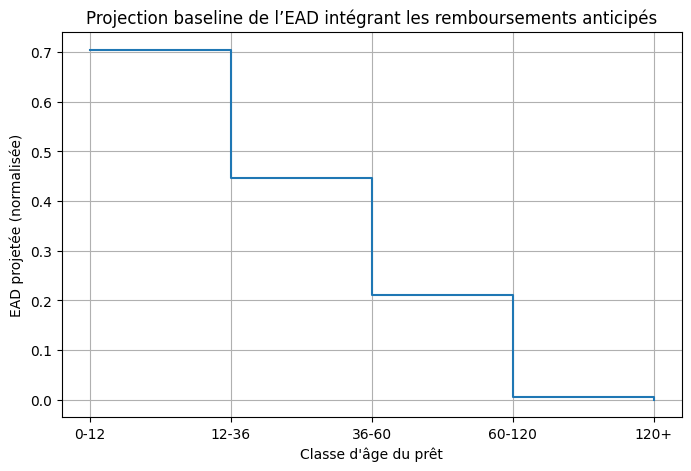

In [50]:
plt.figure(figsize=(8, 5))
plt.step(
    baseline_er["AGE_PRET_BIN"].astype(str),
    baseline_er["EAD_proj"],
    where="post"
)
plt.xlabel("Classe d'âge du prêt")
plt.ylabel("EAD projetée (normalisée)")
plt.title("Projection baseline de l’EAD intégrant les remboursements anticipés")
plt.grid(True)
plt.show()


## 5.6 Projection baseline de l’EAD intégrant les remboursements anticipés

La figure ci-dessus représente la trajectoire de l’exposition au défaut projetée (`EAD_proj`), normalisée par l’exposition initiale à la date d’arrêté, en intégrant la baseline des remboursements anticipés construite par classes d’âge du prêt.

Cette projection est obtenue à partir de la structure cumulée des remboursements anticipés, selon la relation :

\[
EAD_t = EAD_0 \times (1 - ER^{cum}_t)
\]

où \( ER^{cum}_t \) désigne le remboursement anticipé cumulé jusqu’à la classe d’âge \( t \).

---

### Lecture de la trajectoire projetée

La trajectoire de l’EAD projetée présente une décroissance par paliers, directement liée à la segmentation par classes d’âge.

#### Classe 0–12 mois  
L’EAD projetée reste élevée, autour de 70 % de l’exposition initiale. Cette phase correspond au début de vie du prêt, durant laquelle les remboursements anticipés sont fréquents mais majoritairement partiels. L’encours diminue donc progressivement sans extinction massive.

#### Classe 12–36 mois  
Une baisse marquée de l’EAD projetée est observée, traduisant l’accumulation des remboursements anticipés au cours de la phase d’installation du prêt. Cette période concentre une part importante de la sortie des encours, ce qui est cohérent avec des comportements de refinancement ou d’ajustement en début de vie.

#### Classe 36–60 mois  
La diminution de l’EAD se poursuit mais à un rythme plus modéré. Cette phase correspond à une période intermédiaire du cycle de vie du prêt, caractérisée par des remboursements anticipés moins fréquents mais toujours significatifs.

#### Classe 60–120 mois  
La projection montre une quasi-extinction de l’EAD. Les remboursements anticipés cumulés atteignent un niveau très élevé, traduisant une forte sortie des encours avant l’échéance contractuelle finale. Cette dynamique est cohérente avec des comportements de clôture anticipée à maturité avancée.

#### Classe 120+ mois  
L’EAD projetée devient quasi nulle. Cette classe regroupe les contrats résiduels en fin de vie, peu nombreux, pour lesquels l’exposition restante est marginale. La projection reflète une extinction quasi complète du portefeuille.

---

### Interprétation économique globale

Cette trajectoire met en évidence une **sortie rapide des encours bien avant la maturité contractuelle**, confirmant que l’hypothèse d’une EAD purement contractuelle conduirait à une surestimation de l’exposition future.

La décroissance par paliers illustre clairement le rôle central des remboursements anticipés dans la dynamique de l’EAD et justifie leur intégration explicite dans un cadre IFRS 9.

---

### Implications IFRS 9

Cette projection baseline constitue une première approximation opérationnelle de l’EAD comportementale :

- elle est **cohérente avec une approche cash-flow based**, conforme aux principes IFRS 9 ;
- elle fournit une trajectoire d’exposition réaliste pour le calcul des pertes de crédit attendues ;
- elle peut être utilisée comme **référence minimale** pour évaluer l’apport de modèles plus sophistiqués.

En particulier, l’impact des remboursements anticipés sur l’EAD projetée suggère un effet potentiellement significatif sur les ECL, en réduisant fortement l’exposition aux horizons lointains.

---

### Limites et perspectives

Cette projection repose sur une baseline agrégée par classes d’âge et ne tient pas compte, à ce stade, de l’hétérogénéité individuelle ou segmentaire (produit, taux, profil client). Elle constitue néanmoins une base robuste et interprétable, sur laquelle peuvent s’appuyer des développements ultérieurs, notamment une modélisation en deux étapes distinguant l’occurrence et l’intensité des remboursements anticipés.

---

### Conclusion intermédiaire

La projection baseline de l’EAD met en évidence l’importance des remboursements anticipés dans la dynamique des encours et confirme leur rôle structurant dans le calcul IFRS 9 des pertes de crédit attendues. Cette étape marque l’aboutissement de la phase de construction de la baseline et ouvre la voie à l’analyse de l’impact sur les ECL et à la mise en œuvre de modèles comportementaux plus avancés.
